# Casi todos los pastos marinos del mundo caben en 5 países

148.506 km² de praderas submarinas en todo el planeta. Y el 69% está en apenas cinco países. Uno solo —Bahamas— guarda más de un tercio.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Global high-resolution mapping of seagrass to support conservation* — Peng et al. (2026), *Nature*.
**DOI:** [10.1038/s41586-026-10704-3](https://doi.org/10.1038/s41586-026-10704-3)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-30-pastos-marinos-mapa-global/notebook.ipynb)

## Qué hicieron

El equipo construyó el primer mapa global de pastos marinos a 10 metros de resolución. Para lograrlo procesaron 4,75 millones de imágenes del satélite Sentinel-2 y entrenaron un clasificador de aprendizaje profundo (*deep learning*) que distingue las praderas en aguas claras y poco profundas.

Compararon dos ventanas de tiempo —2019-2020 y 2023-2024— para medir no solo dónde están los pastos, sino cuánto se han movido. Los datos que abrimos aquí son los que acompañan al paper: el área por país y el área por celda de 1 grado del planeta.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TOTAL_GLOBAL = 148506        # km² de pastos marinos en el mundo (headline del paper)
TOP_N        = 8             # cuántos países mostrar antes de agrupar el resto
COLOR_DATOS      = '#2563EB'  # azul CaM
COLOR_ALERTA     = '#DC2626'  # rojo — el dato que domina
COLOR_SECUNDARIO = '#059669'  # emerald
COLOR_REFERENCIA = '#D97706'  # amber — umbral/referencia
COLOR_CONTEXTO   = '#BBBBBB'  # gris — el resto
FUENTE = 'Fuente: Peng et al. (2026), Nature | Datos: Source Data + Zenodo 18612239'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
paises = pd.read_csv('datos/seagrass_por_pais.csv')
grid   = pd.read_csv('datos/seagrass_grid_2019.csv')

print(f'Países con pastos marinos: {len(paises)}')
print(f'Área total (suma por país): {paises.seagrass_area_km2.sum():,.0f} km²')
print(f'Área total (suma por celda): {grid.seagrass_area_km2.sum():,.0f} km²')
print(f'Headline del paper:          {TOTAL_GLOBAL:,} km²')

Países con pastos marinos: 119
Área total (suma por país): 148,508 km²
Área total (suma por celda): 148,507 km²
Headline del paper:          148,506 km²


## Aquí está.

Ordenamos los 119 países por área de pastos marinos.

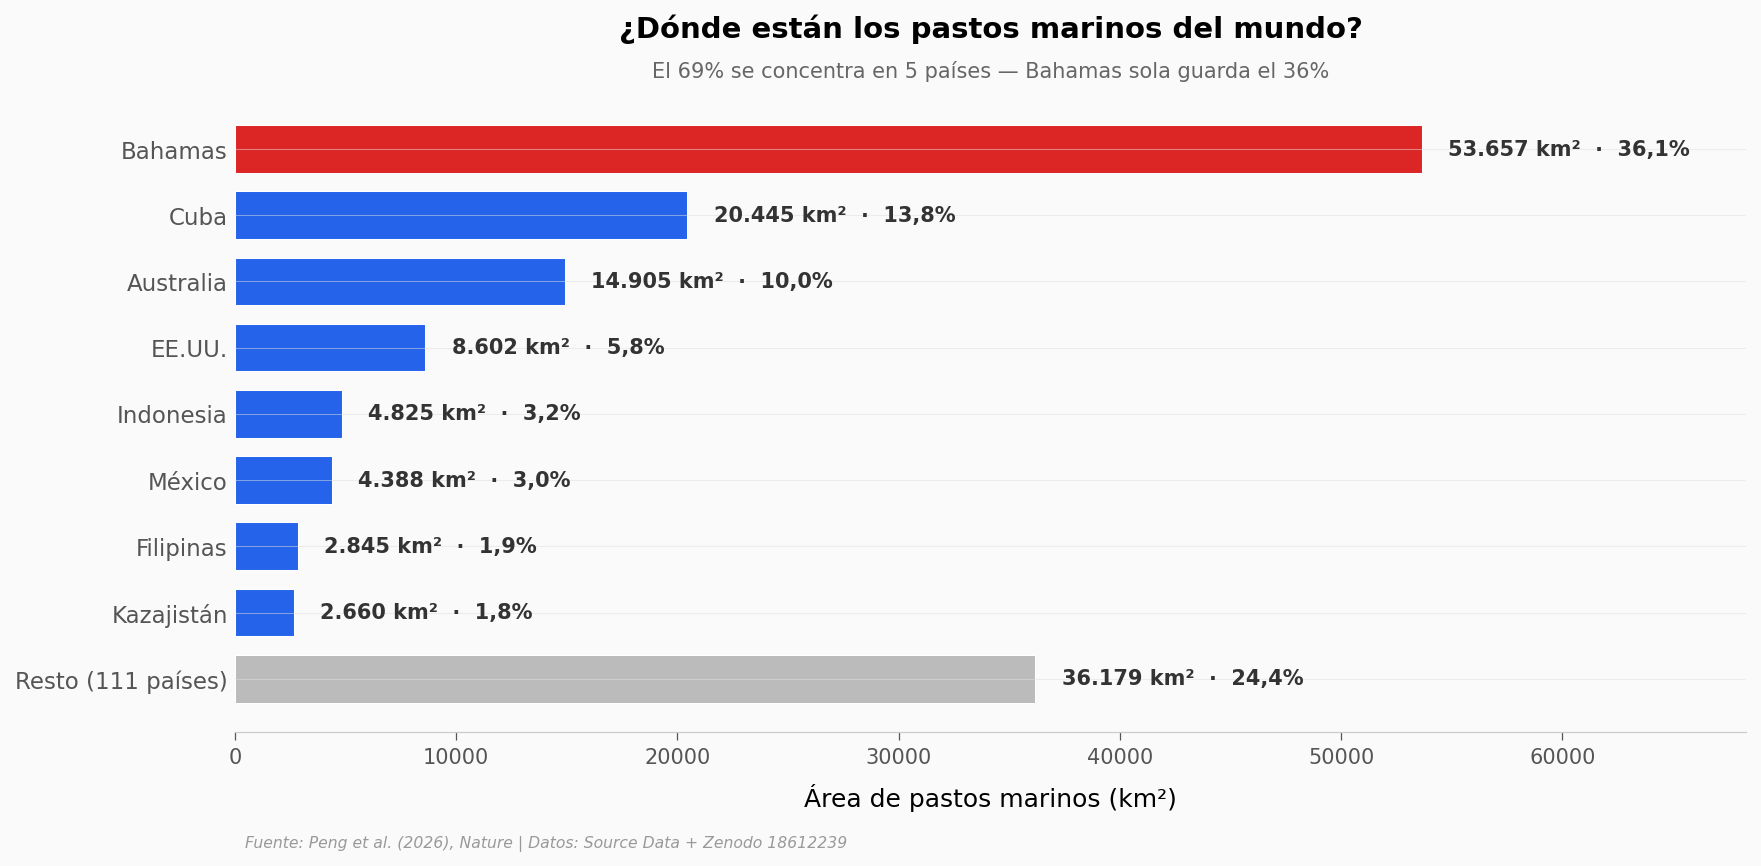

In [2]:
orden = paises.sort_values('seagrass_area_km2', ascending=False).reset_index(drop=True)
top = orden.head(TOP_N).copy()
resto_area = orden.iloc[TOP_N:].seagrass_area_km2.sum()
resto_n = len(orden) - TOP_N

# Etiquetas legibles
nombres = {'Bahamas': 'Bahamas', 'Cuba': 'Cuba', 'Australia': 'Australia',
           'United States': 'EE.UU.', 'Indonesia': 'Indonesia', 'Mexico': 'México',
           'Philippines': 'Filipinas', 'Kazakhstan': 'Kazajistán'}
labels = [nombres.get(p, p) for p in top.sovereign] + [f'Resto ({resto_n} países)']
valores = list(top.seagrass_area_km2) + [resto_area]
total = paises.seagrass_area_km2.sum()
pct = [100 * v / total for v in valores]

# Bahamas en rojo (domina), el resto en gris, los demás en azul
colores = []
for lab in labels:
    if lab == 'Bahamas':
        colores.append(COLOR_ALERTA)
    elif lab.startswith('Resto'):
        colores.append(COLOR_CONTEXTO)
    else:
        colores.append(COLOR_DATOS)

fig, ax = plt.subplots(figsize=(13, 5.5))
y = np.arange(len(labels))[::-1]
ax.barh(y, valores, color=colores, edgecolor='white', height=0.72)
for yi, v, p, lab in zip(y, valores, pct, labels):
    etiqueta = f"{v:,.0f}".replace(',', '.') + ' km²  ·  ' + f"{p:.1f}".replace('.', ',') + '%'
    ax.text(v + total*0.008, yi, etiqueta,
            va='center', fontsize=10, fontweight='bold',
            color='#333333')
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlim(0, total*0.46)
ax.set_xlabel('Área de pastos marinos (km²)')
ax.set_title('¿Dónde están los pastos marinos del mundo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El 69% se concentra en 5 países — Bahamas sola guarda el 36%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.spines['left'].set_visible(False)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/concentracion_paises.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención no es solo que Bahamas lidere: es la caída tan brusca después. Bahamas (36,1%) y Cuba (13,8%) juntas pasan la mitad del Caribe. Para cuando llegamos a Indonesia, el quinto país, ya cubrimos el 69% del planeta. Los 114 países restantes se reparten menos de un tercio.

Tres países —Bahamas, Cuba y Australia— concentran el 59,9% del total. La mediana por país es de apenas 108,7 km² (rango intercuartílico 25,8-572,8): la mayoría tiene franjas pequeñas, y un puñado tiene casi todo.

## ¿Y en qué parte del planeta?

Esa concentración por país tiene una huella geográfica clara. Llevemos los datos a la latitud: ¿en qué franjas del globo se acumulan los pastos?

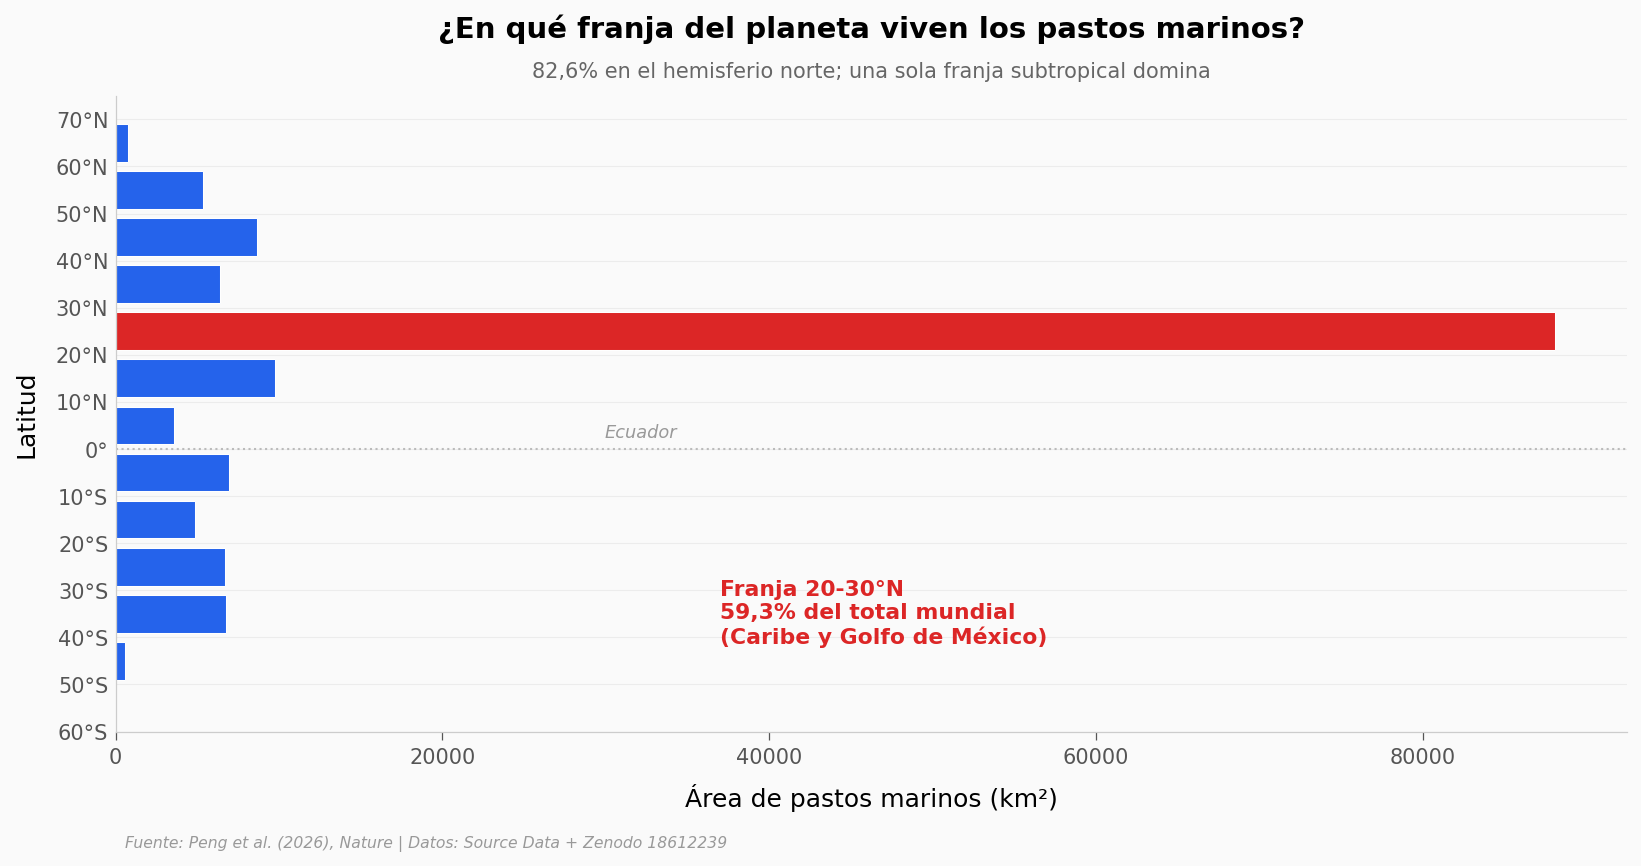

In [3]:
# Sumar área por banda de 10° de latitud
bins = np.arange(-60, 71, 10)
grid['banda'] = pd.cut(grid.grid_center_latitude_deg, bins=bins, right=False)
por_banda = grid.groupby('banda', observed=True).seagrass_area_km2.sum()
centros = [interval.left + 5 for interval in por_banda.index]
areas = por_banda.values
total_g = grid.seagrass_area_km2.sum()

# Resaltar la banda 20-30N (Caribe/Golfo)
colores = [COLOR_ALERTA if 20 <= c < 30 else COLOR_DATOS for c in centros]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.barh(centros, areas, height=8, color=colores, edgecolor='white')
ax.axhline(0, color=COLOR_CONTEXTO, lw=1, linestyle=':')
ax.text(areas.max()*0.34, 1.5, 'Ecuador', fontsize=8.5, color='#999999',
        va='bottom', style='italic')
ax.text(areas.max()*0.42, -35,
        'Franja 20-30°N\n59,3% del total mundial\n(Caribe y Golfo de México)',
        fontsize=10.5, fontweight='bold', color=COLOR_ALERTA, va='center')
ax.set_yticks(np.arange(-60, 71, 10))
ax.set_yticklabels([f'{abs(t)}°{"N" if t>0 else ("S" if t<0 else "")}' for t in np.arange(-60,71,10)])
ax.set_xlabel('Área de pastos marinos (km²)')
ax.set_ylabel('Latitud')
ax.set_title('¿En qué franja del planeta viven los pastos marinos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '82,6% en el hemisferio norte; una sola franja subtropical domina',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_latitud.png', dpi=200, bbox_inches='tight')
plt.show()

## El carbono sigue al mapa

Los pastos marinos no son solo refugio de biodiversidad: atrapan carbono orgánico en el sedimento. El dataset trae cuánto guarda cada país. La pregunta natural: ¿el carbono se reparte igual que el área, o algunos pastos son más densos que otros?

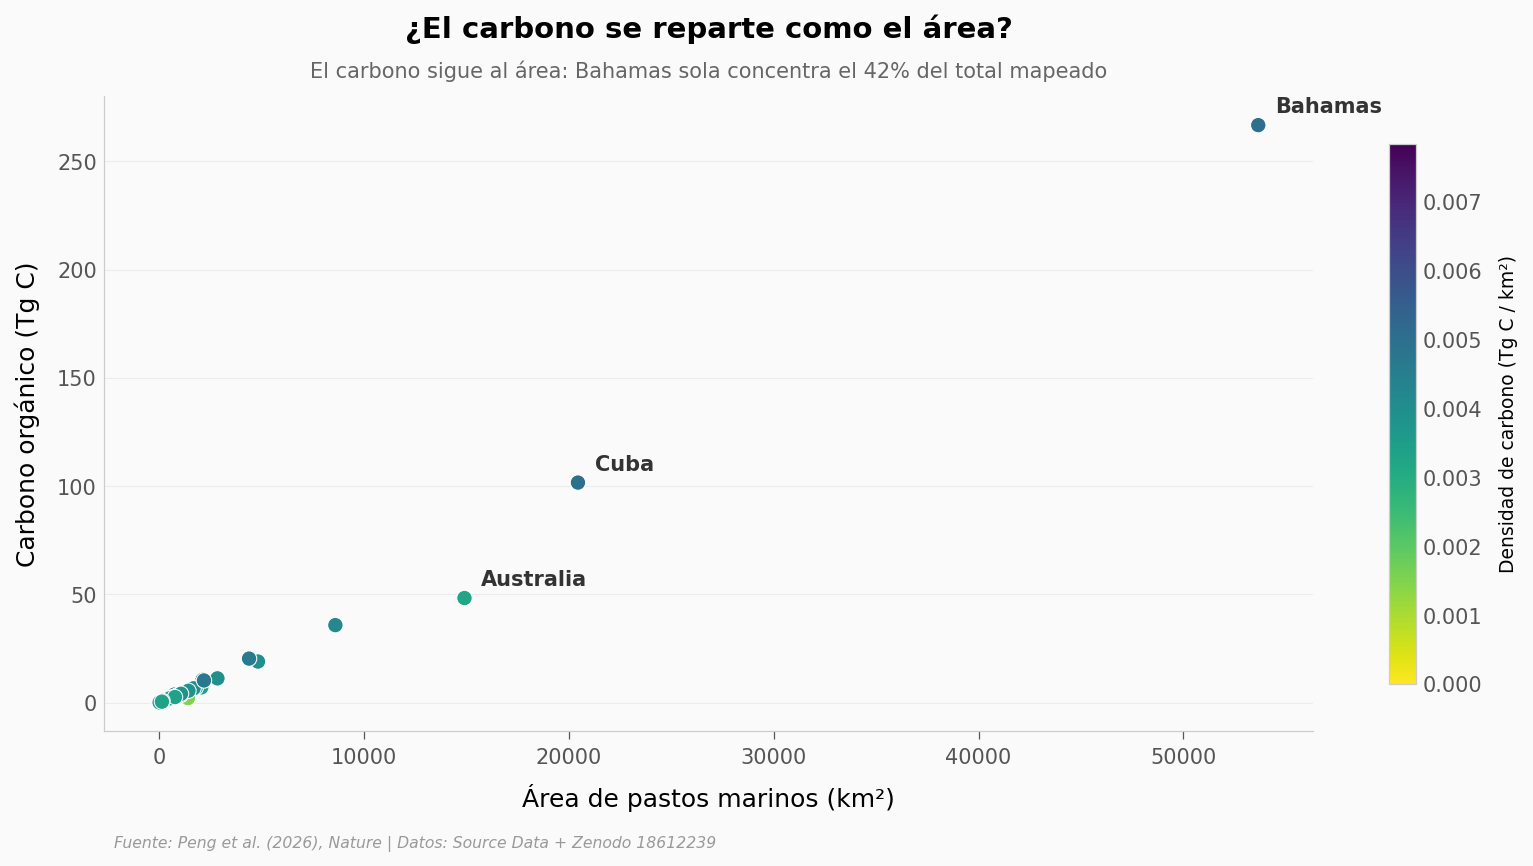

Carbono total mapeado: 639 Tg C
Bahamas: 41.7% del carbono


In [4]:
c = paises.dropna(subset=['organic_carbon_tg_c']).copy()
c['densidad'] = c.organic_carbon_tg_c / c.seagrass_area_km2  # Tg C por km²

fig, ax = plt.subplots(figsize=(13, 5.5))
sc = ax.scatter(c.seagrass_area_km2, c.organic_carbon_tg_c,
                c=c.densidad, cmap='viridis_r', s=55,
                edgecolors='white', linewidths=0.5, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('Densidad de carbono (Tg C / km²)', fontsize=9)

# Anotar los grandes
for _, r in c.nlargest(3, 'seagrass_area_km2').iterrows():
    nom = {'Bahamas':'Bahamas','Cuba':'Cuba','Australia':'Australia'}.get(r.sovereign, r.sovereign)
    ax.annotate(nom, (r.seagrass_area_km2, r.organic_carbon_tg_c),
                xytext=(8, 6), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#333333')
ax.set_xlabel('Área de pastos marinos (km²)')
ax.set_ylabel('Carbono orgánico (Tg C)')
ax.set_title('¿El carbono se reparte como el área?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El carbono sigue al área: Bahamas sola concentra el 42% del total mapeado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/area_vs_carbono.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Carbono total mapeado: {c.organic_carbon_tg_c.sum():.0f} Tg C')
print(f'Bahamas: {100*c[c.sovereign=="Bahamas"].organic_carbon_tg_c.values[0]/c.organic_carbon_tg_c.sum():.1f}% del carbono')

## ¿Qué tan concentrado está, en realidad?

Bajamos del nivel país al nivel celda: el planeta dividido en cuadrículas de 1 grado. De las 1.987 celdas con algo de pasto marino, ¿cuántas hacen el grueso del trabajo?

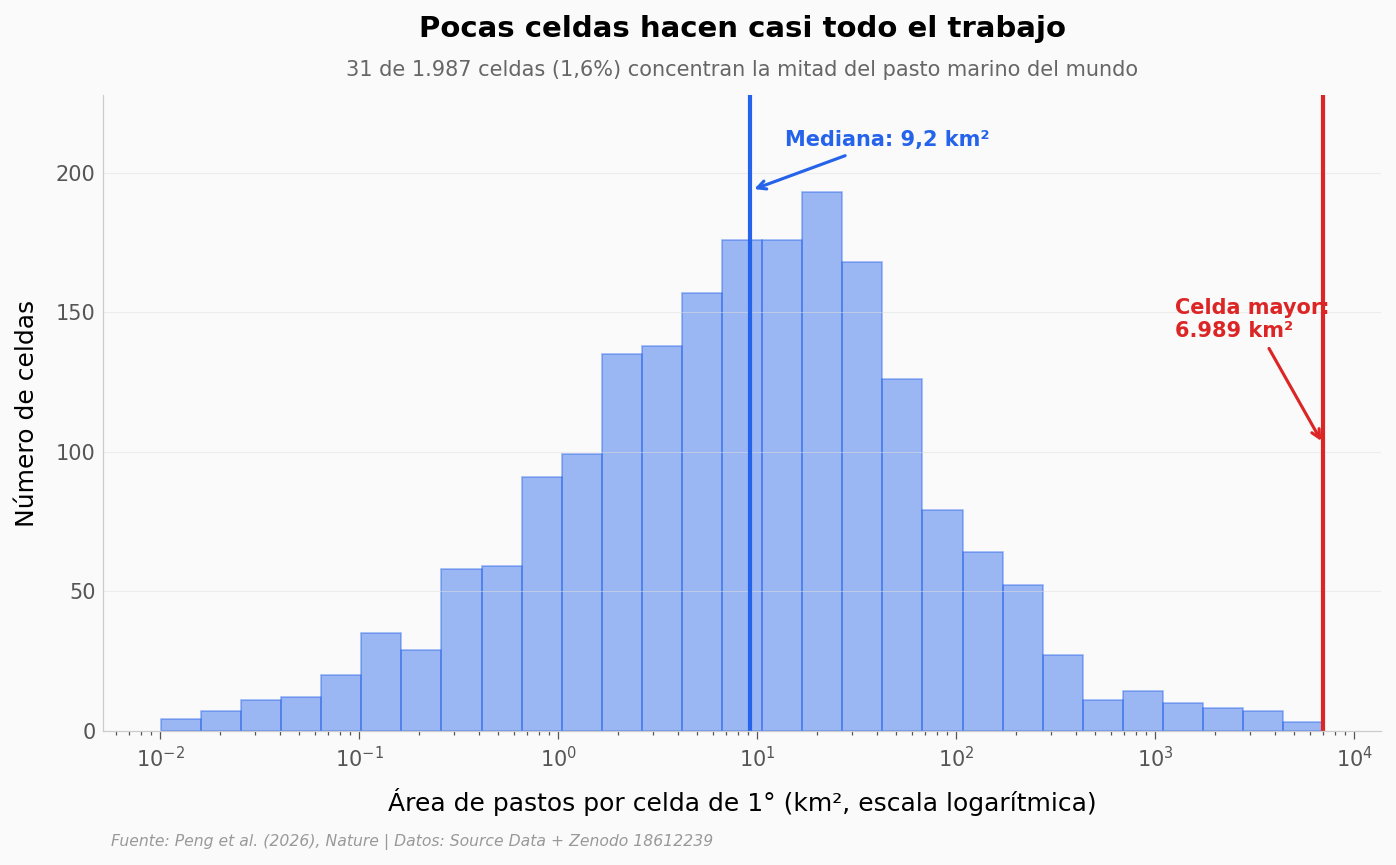

31 de 1987 celdas (1.6%) concentran la mitad del área


In [5]:
g = grid.seagrass_area_km2.values
mediana = np.median(g)

# Distribución muy sesgada (skew 10,7): histograma en escala log para que sea legible
logbins = np.logspace(np.log10(g.min()+0.01), np.log10(g.max()), 30)
fig, ax = plt.subplots(figsize=(11, 5.5))
n, bins, _ = ax.hist(g, bins=logbins, color=COLOR_DATOS, alpha=0.45,
                     edgecolor=COLOR_DATOS, linewidth=0.8)
ax.set_xscale('log')
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Línea de la mediana
ax.axvline(mediana, color=COLOR_DATOS, lw=2)
ax.annotate(f'Mediana: {mediana:.1f} km²'.replace('.', ','),
            xy=(mediana, y_max*0.85), xytext=(mediana*1.5, y_max*0.92),
            fontsize=10, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))

# Las megaceldas a la derecha
maxc = g.max()
ax.axvline(maxc, color=COLOR_ALERTA, lw=2)
ax.annotate(f'Celda mayor:\n{maxc:,.0f} km²'.replace(',', '.'),
            xy=(maxc, y_max*0.45), xytext=(maxc*0.18, y_max*0.62),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xlabel('Área de pastos por celda de 1° (km², escala logarítmica)')
ax.set_ylabel('Número de celdas')
ax.set_title('Pocas celdas hacen casi todo el trabajo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '31 de 1.987 celdas (1,6%) concentran la mitad del pasto marino del mundo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_celdas.png', dpi=200, bbox_inches='tight')
plt.show()

# Cuántas celdas concentran la mitad
gs = np.sort(g)[::-1]
n_half = int(np.argmax(np.cumsum(gs) >= g.sum()/2)) + 1
print(f'{n_half} de {len(g)} celdas ({100*n_half/len(g):.1f}%) concentran la mitad del área')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| 148.506 km² de pastos marinos en el mundo | ✅ | Suma por país (148.508) y por celda (148.507) reproducen el titular del paper con <0,01% de diferencia |
| El 69% se concentra en 5 países | ✅ | Bahamas 36,1% · Cuba 13,8% · Australia 10,0% · EE.UU. 5,8% · Indonesia 3,2% = 69,0% |
| Una sola franja (20-30°N) tiene ~59% | ✅ | 88.100 km² de 148.507; Caribe y Golfo de México. 82,6% del total está en el hemisferio norte |
| 31 celdas de 1° concentran la mitad | ✅ | 31 de 1.987 celdas (1,6%); distribución muy sesgada (asimetría 10,7) |
| Bahamas guarda ~42% del carbono mapeado | ✅ | 266,7 de 639 Tg C; trópicos con mayor densidad de carbono por km² |
| Solo 21% está en áreas marinas protegidas | ⚠️ | Cifra del paper; no está en los datos abiertos, no la recalculamos aquí |
| Se perdió 4% y se degradó 4,2% (2019-2024) | ⚠️ | Cifras del abstract (5.969 km² perdidos, 6.221 km² degradados). La columna de pérdida por país del dataset mide otra cosa (pérdida bruta por píxel, 44.171 km²) y **no** equivale a ese 4% |

> **Limitaciones:** el mapa cubre aguas claras y poco profundas, donde el satélite ve el fondo — las praderas en aguas turbias o profundas quedan fuera. Es un censo observacional: dice *cuánto* y *dónde*, no *por qué* se perdió pasto. Y la pérdida neta del abstract (5.969 km²) no se puede reconstruir desde la tabla por país que abrimos aquí: esa columna reporta pérdida bruta, una métrica distinta.

## Ahora tú

Los datos están cargados. Tres preguntas para explorar:

1. **¿Cómo cambia el ranking si miras carbono en vez de área?** Pista: ordena `paises` por `organic_carbon_tg_c` y compara el top 5 con el de área.
2. **¿Qué tan desigual es la repartición?** Pista: construye una curva de concentración — ordena las celdas de mayor a menor y grafica el % acumulado de área contra el % acumulado de celdas.
3. **¿Dónde está el carbono más denso?** Pista: calcula `organic_carbon_tg_c / seagrass_area_km2` por país y mira qué regiones encabezan.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántos países necesitas sumar para llegar a cada umbral de área global?
orden = paises.sort_values('seagrass_area_km2', ascending=False).reset_index(drop=True)
total = orden.seagrass_area_km2.sum()
acum = orden.seagrass_area_km2.cumsum() / total * 100

for umbral in [25, 50, 75, 90]:
    n = int((acum < umbral).sum()) + 1
    print(f'{umbral}% del área global → primeros {n} países')

# Cámbialo: ¿y por carbono? Reemplaza 'seagrass_area_km2' por 'organic_carbon_tg_c'

25% del área global → primeros 1 países
50% del área global → primeros 3 países
75% del área global → primeros 8 países
90% del área global → primeros 23 países


## Fuentes

**Paper**: [Global high-resolution mapping of seagrass to support conservation](https://doi.org/10.1038/s41586-026-10704-3)  
*Nature, 2026-06-24* · paywall

**Source Data**: Source Data — per-country extent/loss/carbon (MOESM5) + per-grid extent 2019 (MOESM4) — tablas oficiales que acompañan el paper (mismo DOI).

**Dataset canónico**: [Global 10-meter seagrass maps (2019-2020 and 2023-2024)](https://doi.org/10.5281/zenodo.18612239)  
*Zenodo — mapas globales de 10 m (2019-2020 y 2023-2024)*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Datos reproducibles · Notebook generado por [Ciencia a Mordiscos](https://cienciaamordiscos.com) · Repo: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)*